# Finetuning GPT Model

## Background

So far, we have built our very own `GPTModel` implementation from first principles.

We then trained it to predict the next token in a sequence. More precisely, this stage of training is called **pretraining**.

Next, we learned how to load OpenAI's pretrained GPT-2 parameters into our own `GPTModel` implementation, allowing us to leverage OpenAI's substantial training investment without spending tens of thousands of dollars on pretraining ourselves.

However, our `GPTModel` still does not behave like mainstream models such as ChatGPT. It can predict the next token, but it does not naturally follow instructions, answer questions, summarize text, classify information, or perform many of the tasks users expect from modern LLMs.

In this computational essay, we will **finetune** our `GPTModel` to follow instructions—the fundamental capability that makes modern LLMs general-purpose assistants.

Instruction finetuning is more than just another application of the `GPTModel`. It represents a major paradigm shift in AI. By teaching a pretrained language model to follow human instructions, the same next-token prediction architecture becomes capable of performing a remarkably diverse range of tasks through natural language alone. This breakthrough transformed LLMs from language completion models into general-purpose AI assistants and fundamentally reshaped the direction of modern AI.

## Goal

> Given prompt `What is the capital of Indonesia?`, we should be able to have the response `The capital of Indonesia is Jakarta.`

## Recipe
1. Load the dataset for finetuning.
2. Partition the dataset into training, validation and testing sets.
3. Prepare the dataloaders for each set.
4. Load the pre-trained weights of OpenAI's `GPT-2` model into our very own `GPTModel` implementation.
5. Observe the current performance before finetuning.
6. Start the training loop for finetuning.
7. Observe the performance of our very own `GPTModel` implementation by running inference loop after finetuning.
8. Save the Finetuned model for later use.

## Step 1: Load the dataset for finetuning.

In [15]:
import json

with open("instruction-data.json", "r") as file:
    data = json.load(file)
        
print("Number of training examples:", len(data))

Number of training examples: 1100


## Step 2: Prepare the dataset in the instruction finetuning format.

- (a): Write a instruction formatter for prompt.
- (b): Prepare a dataset class to load one training example.
- (c): Make the batch of training examples with varying number of tokens symmetric.
- (d): Prepare the dataloader for loading training examples in batches.
- (e): Verify shape of data from dataloader.

### 2(a): Write a instruction formatter for prompt.

In [2]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = (
        f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )
    
    return instruction_text + input_text

# Usage
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


### 2(b): Prepare a dataset class to load one training example.

In [3]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

### 2(c): Make the batch of training examples with varying number of tokens symmetric.

In [4]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=1024,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]


        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [5]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


**Note:** _We are replacing `-100` for more than one `<|endoftext|>` token because we do want to influence training with this token to let the model learn when to stop generating token but do not want to influence too much with multiple such tokens._

### 2(d): Prepare the dataloader for loading training examples in batches.

In [6]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

# Only use 85% of data for training, 10% for testing, 5% for validation.
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("Training dataset size:", len(train_data))
print("Testing dataset size:", len(test_data))
print("Validation dataset size:", len(val_data))

# Prepare the training dataset and the loader for batching of training examples.
training_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    training_dataset,
    batch_size=batch_size,
    collate_fn=custom_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

# Similarly, prepare validation examples for reference unseen by the model during training to avoid overfiting.
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=custom_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

# Similarly, prepare testing examples for reference unseen by the model during training to avoid overfiting.
test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=custom_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

Training dataset size: 935
Testing dataset size: 110
Validation dataset size: 55


### 2(e): Verify shape of data from dataloader.

In [7]:
print("Shape of training data:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Shape of training data:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 6

## Step 4: Load the pre-trained weights of OpenAI's `GPT-2` model into our very own `GPTModel` implementation.

In [8]:
import sys 
sys.path.append("../..")

from gpt_module import GPTModel
from embeddings_module import text_to_token_ids, token_ids_to_text
from gpt_training_module import load_weights_into_gpt, download_and_load_gpt2, text_generation_app

BASE_CONFIG = {
    "vocab_size": 50257,          # Vocabulary size
    "context_window_size": 1024,  # Context length
    "drop_rate": 0.0,             # Dropout rate
    "qkv_bias": True              # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

settings, params = download_and_load_gpt2(
    model_size=model_size, 
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe


## Step 5: Observe the current performance before finetuning.
- (a): Observe qualitatively.
- (b): Observe quantitatively.

### 5(a): Observe qualitatively.

In [9]:
torch.manual_seed(123)

# Pick any example to observe the quality of instruction following
training_example = train_data[12]
input_text = format_input(training_example)

token_ids = text_generation_app(
    model=model,
    input_text=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_window_size=BASE_CONFIG["context_window_size"],
    eos_id=50256,
)

generated_text = token_ids_to_text(token_ids, tokenizer)

# Extract only the newly generated tokens as a response from the model.
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Answer:

### Instruction:

What is the capital of Indonesia?

### Answer:

### Instruction:

What is the capital


**Note:** _This output shows that the pretrained model is not yet capable of correctly following the given instruction. While it does create a Answer section, it simply repeats the original input sentence and part of the instruction, failing to convert the active sentence to passive voice as requested. So, let’s now implement the fine-tuning process to improve the model’s ability to comprehend and appropriately respond to such requests._

### 5(b): Observe quantitatively.

In [10]:
from gpt_training_module import load_weights_into_gpt, download_and_load_gpt2, text_generation_app
from gpt_training_module import calc_loss_loader, calc_loss_batch

torch.manual_seed(123)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.825879430770874
Validation loss: 3.761904001235962


**Note:** _Loss value is too high as it should be approximately zero._

## Step 6: Finetuning Loop.

- (a): Start the training loop for finetuning.
- (b): Visualize the learning progress overtime.

In [11]:
import time
from gpt_training_module import plot_losses
from gpt_training_module import train_model_simple

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=0.00005, weight_decay=0.1
)

## Start the training loop
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=2, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()

execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.102
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.945
Ep 1 (Step 000015): Train loss 0.856, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.753, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.798, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.715, Val loss 0.809
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.790
Ep 1 (Step 000050): Train loss 0.662, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.764
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.652, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.532, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.569, Val loss 0.729
Ep 1 (Step 000080): Train loss 0.605, Val loss 0.725
Ep 1 (Step 000085): Train loss 0.509, Val loss 0.710
Ep 1 (Step 000090): Train loss 0.562, Val loss

### (b): Visualize Learning Progress Overtime

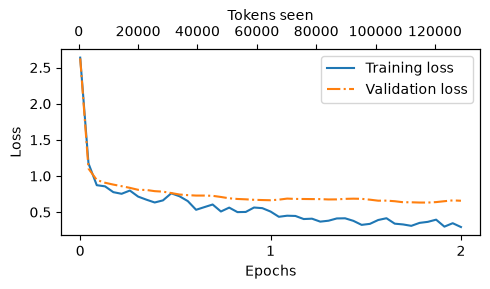

In [12]:
num_epochs = 2
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## Step 7: Observe the performance of our very own `GPTModel` implementation by running inference loop after finetuning.

In [13]:
torch.manual_seed(123)

for entry in test_data[:3]:
    input_text = format_input(entry)
    token_ids = text_generation_app(
        model=model,
        input_text=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_window_size=BASE_CONFIG["context_window_size"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)

    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )
    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a cheetah.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Pre

**Note:** _Observe the Model response is coherent and ._

### Validation: Did we acheive our goal?

In [18]:
torch.manual_seed(123)

# Pick any example to observe the quality of instruction following
training_example = train_data[12]
input_text = format_input(training_example)

token_ids = text_generation_app(
    model=model,
    input_text=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_window_size=BASE_CONFIG["context_window_size"],
    eos_id=50256,
)

generated_text = token_ids_to_text(token_ids, tokenizer)

# Extract only the newly generated tokens as a response from the model.
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:
The capital of Indonesia is Jakarta.


**Note:** _Finally, our very own `GPTModel` implementation is able to generated correct answer for the question asked by the user. So we have acheived our initially stated goal._

## Step 8: Save the Finetuned model for later use.

In [16]:
import re

file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as gpt2-medium355M-sft.pth


## What Did We Learn?

In this computational essay, we transformed our pretrained `GPTModel` into an **instruction-following language model** through supervised finetuning.

We learned:

* How to prepare an instruction-following dataset by structuring each training example into **Instruction**, **Input**, and **Response** sections.
* How to tokenize, batch, and pad instruction-response examples for efficient finetuning.
* Why pretrained GPT models are excellent language models but do not naturally follow user instructions.
* How to load OpenAI's pretrained GPT-2 parameters into our own `GPTModel` implementation as the starting point for finetuning.
* How to measure the model's instruction-following capability before finetuning, both qualitatively and quantitatively.
* How to finetune the pretrained model on an instruction dataset while monitoring training and validation loss.
* How to evaluate the finetuned model on unseen instruction examples.
* How to save the finetuned model for later inference and downstream applications.

The most important insight is that **instruction following is not a new architecture**. The same GPT architecture that was pretrained to predict the next token becomes a general-purpose AI assistant simply by continuing its training on instruction-response examples.

This explains why modern models such as ChatGPT, Claude, and Gemini all share the same fundamental Transformer architecture yet are capable of answering questions, summarizing text, writing code, translating languages, and performing countless other tasks. The breakthrough lies not in changing the architecture, but in **teaching the pretrained language model to follow human instructions**.

At this point, we have completed the entire journey of reconstructing a modern instruction-following GPT—from first principles to a model capable of responding coherently to natural language instructions.
